# Advanced Machine Learning and MLOps
## Project: Tourism Package Prediction

# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.

## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.

## Pre-requisites

**This notebook runs locally (Jupyter), not in Google Colab.** The MLOps pipeline is deployed the same way the template describes, but the plumbing is adapted for a local environment:

1. **GitHub repository:** [github.com/niteshtripa/tourism-package-prediction](https://github.com/niteshtripa/tourism-package-prediction) — public repo created for this project.
2. **GitHub Personal Access Token (classic)** with `repo` and `workflow` scopes, created at GitHub -> Settings -> Developer settings -> Personal access tokens. Instead of a Colab secret, it is read from the `GH_TOKEN` environment variable in this local session (never hard-coded in the notebook, and never printed to output).
3. **GitHub Actions** runs the ML pipeline (data registration -> data prep -> model training/tracking -> commit model back to the repo) automatically on every push to `main`.
4. **Streamlit Community Cloud** (share.streamlit.io) hosts the live app, deployed from `tourism_project/deployment/app.py` in the same repo.
5. **MLflow** tracks experiments locally (SQLite backend) during development in this notebook; no ngrok/Colab tunnel is required outside Colab.

## Installing and Importing Necessary Libraries

In [ ]:
!pip install -q mlflow==3.0.1 xgboost==2.1.1

In [ ]:
import os
import subprocess

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
import joblib
import mlflow

## Configuration

In [ ]:
# Edit these two values, then run every cell top to bottom.
GITHUB_USERNAME = "niteshtripa"
REPO_NAME       = "tourism-package-prediction"

REPO   = f"{GITHUB_USERNAME}/{REPO_NAME}"
BRANCH = "main"
REPO_URL = f"https://github.com/{REPO}"
print("Target repository:", REPO_URL)

### GitHub Token

The GitHub PAT is read from the `GH_TOKEN` environment variable of this local session (set beforehand in the terminal used to launch Jupyter) rather than a Colab secret, since this notebook is executed locally. It is never printed or written to a file — every helper below redacts it from any command output before printing.

In [ ]:
GH_TOKEN = os.environ.get("GH_TOKEN")
print("GH_TOKEN loaded:", bool(GH_TOKEN))

# Model Building

In [ ]:
# Create a master folder to keep all files created when executing the below code cells
os.makedirs("tourism_project", exist_ok=True)

In [ ]:
# Create a folder for storing the model building files
os.makedirs("tourism_project/model_building", exist_ok=True)

## Data Registration

In [ ]:
os.makedirs("tourism_project/data", exist_ok=True)

`tourism.csv` has been placed in `tourism_project/data/`. The dataset is registered with `tourism_project/model_building/data_register.py`, which checks that the expected columns are present and prints a summary.

In [ ]:
%%writefile tourism_project/model_building/data_register.py
"""
Registers the tourism dataset: verifies it has the expected schema and
prints a short summary. Run from the repo root:

    python tourism_project/model_building/data_register.py
"""

import os
import sys

import pandas as pd

DATA_PATH = os.path.join("tourism_project", "data", "tourism.csv")

EXPECTED_COLUMNS = [
    "CustomerID",
    "ProdTaken",
    "Age",
    "TypeofContact",
    "CityTier",
    "DurationOfPitch",
    "Occupation",
    "Gender",
    "NumberOfPersonVisiting",
    "NumberOfFollowups",
    "ProductPitched",
    "PreferredPropertyStar",
    "MaritalStatus",
    "NumberOfTrips",
    "Passport",
    "PitchSatisfactionScore",
    "OwnCar",
    "NumberOfChildrenVisiting",
    "Designation",
    "MonthlyIncome",
]


def register_dataset(data_path: str = DATA_PATH) -> pd.DataFrame:
    if not os.path.exists(data_path):
        raise FileNotFoundError(
            f"Dataset not found at '{data_path}'. Make sure tourism.csv "
            "has been added to the tourism_project/data folder."
        )

    df = pd.read_csv(data_path)

    missing_columns = [col for col in EXPECTED_COLUMNS if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Dataset is missing expected columns: {missing_columns}")

    print("Dataset registered successfully")
    print(f"Path            : {data_path}")
    print(f"Rows            : {df.shape[0]}")
    print(f"Columns         : {df.shape[1]}")
    print(f"Target column   : ProdTaken")
    print(f"Class balance   :\n{df['ProdTaken'].value_counts(normalize=True).round(3)}")
    print(f"Missing values  : {int(df.isnull().sum().sum())}")
    print(f"Duplicate rows  : {int(df.duplicated().sum())}")

    return df


if __name__ == "__main__":
    try:
        register_dataset()
    except (FileNotFoundError, ValueError) as exc:
        print(f"Data registration failed: {exc}", file=sys.stderr)
        sys.exit(1)


In [ ]:
!python tourism_project/model_building/data_register.py

## Data Preparation

`tourism_project/model_building/prep.py` loads the dataset from the repository data folder, drops identifier columns that carry no predictive signal (`Unnamed: 0`, `CustomerID`), fixes two data-entry issues (`"Fe Male"` -> `"Female"`, `"Unmarried"` -> `"Single"`), and splits the data into training and testing sets, saving them locally as CSV files. The GitHub Actions workflow passes these split files to the next job as a workflow artifact.

In [ ]:
%%writefile tourism_project/model_building/prep.py
"""
Cleans the tourism dataset and creates train/test splits. Run from the
repo root:

    python tourism_project/model_building/prep.py

Writes Xtrain.csv, Xtest.csv, ytrain.csv, ytest.csv to the repo root so the
GitHub Actions workflow can upload them as a job artifact for the next job.
"""

import os

import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = os.path.join("tourism_project", "data", "tourism.csv")
TARGET_COLUMN = "ProdTaken"

# Identifier columns carry no predictive signal and must be dropped before
# modeling.
COLUMNS_TO_DROP = ["Unnamed: 0", "CustomerID"]


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop(columns=[c for c in COLUMNS_TO_DROP if c in df.columns])
    df = df.drop_duplicates()

    # "Fe Male" is a data-entry typo for "Female".
    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].replace({"Fe Male": "Female"})

    # "Unmarried" and "Single" describe the same marital status category.
    if "MaritalStatus" in df.columns:
        df["MaritalStatus"] = df["MaritalStatus"].replace({"Unmarried": "Single"})

    return df


def prepare_data(data_path: str = DATA_PATH, test_size: float = 0.2, random_state: int = 42):
    df = pd.read_csv(data_path)
    df = clean_data(df)

    X = df.drop(columns=[TARGET_COLUMN])
    y = df[TARGET_COLUMN]

    Xtrain, Xtest, ytrain, ytest = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    Xtrain.to_csv("Xtrain.csv", index=False)
    Xtest.to_csv("Xtest.csv", index=False)
    ytrain.to_csv("ytrain.csv", index=False)
    ytest.to_csv("ytest.csv", index=False)

    print(f"Cleaned dataset shape : {df.shape}")
    print(f"Train shape           : {Xtrain.shape}")
    print(f"Test shape            : {Xtest.shape}")
    print("Saved Xtrain.csv, Xtest.csv, ytrain.csv, ytest.csv")

    return Xtrain, Xtest, ytrain, ytest


if __name__ == "__main__":
    prepare_data()


In [ ]:
!python tourism_project/model_building/prep.py

## Model Training and Registration with Experimentation Tracking

`tourism_project/model_building/train.py` loads the train/test splits, builds a preprocessing + XGBoost pipeline, tunes it with `GridSearchCV`, logs parameters and metrics to MLflow, evaluates the best model, and saves it to `tourism_project/deployment/` so the workflow can commit it into the repo. XGBoost was chosen because it handles the tabular, mixed numeric/categorical features well and the class imbalance (~80/20) is corrected with `scale_pos_weight`.

In [ ]:
%%writefile tourism_project/model_building/train.py
"""
Tunes an XGBoost classifier on the tourism train/test split, tracks the
experiment with MLflow, evaluates the best model, and saves it into
tourism_project/deployment/ so the pipeline can commit it to the repo.

Run from the repo root:

    python tourism_project/model_building/train.py
"""

import os

import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
import xgboost as xgb
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder

NUMERIC_FEATURES = [
    "Age",
    "CityTier",
    "DurationOfPitch",
    "NumberOfPersonVisiting",
    "NumberOfFollowups",
    "PreferredPropertyStar",
    "NumberOfTrips",
    "Passport",
    "PitchSatisfactionScore",
    "OwnCar",
    "NumberOfChildrenVisiting",
    "MonthlyIncome",
]

CATEGORICAL_FEATURES = [
    "TypeofContact",
    "Occupation",
    "Gender",
    "ProductPitched",
    "MaritalStatus",
    "Designation",
]

PARAM_GRID = {
    "xgbclassifier__n_estimators": [100, 200],
    "xgbclassifier__max_depth": [3, 5, 7],
    "xgbclassifier__learning_rate": [0.05, 0.1, 0.2],
}

MODEL_DIR = os.path.join("tourism_project", "deployment")
MODEL_PATH = os.path.join(MODEL_DIR, "model.joblib")


def load_splits():
    Xtrain = pd.read_csv("Xtrain.csv")
    Xtest = pd.read_csv("Xtest.csv")
    ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
    ytest = pd.read_csv("ytest.csv").squeeze("columns")
    return Xtrain, Xtest, ytrain, ytest


def build_pipeline(scale_pos_weight: float) -> Pipeline:
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessor = make_column_transformer(
        (SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        (categorical_transformer, CATEGORICAL_FEATURES),
    )
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
    )
    return make_pipeline(preprocessor, model)


def main():
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("tourism-package-prediction")

    Xtrain, Xtest, ytrain, ytest = load_splits()

    # Counteract the class imbalance (~80/20) so the minority "purchased"
    # class isn't ignored by the model.
    scale_pos_weight = (ytrain == 0).sum() / (ytrain == 1).sum()
    pipeline = build_pipeline(scale_pos_weight)

    with mlflow.start_run():
        search = GridSearchCV(
            pipeline,
            PARAM_GRID,
            scoring="f1",
            cv=3,
            n_jobs=-1,
        )
        search.fit(Xtrain, ytrain)

        best_model = search.best_estimator_
        mlflow.log_params(search.best_params_)
        mlflow.log_param("scale_pos_weight", scale_pos_weight)

        ypred = best_model.predict(Xtest)
        yproba = best_model.predict_proba(Xtest)[:, 1]

        metrics = {
            "accuracy": accuracy_score(ytest, ypred),
            "f1_score": f1_score(ytest, ypred),
            "roc_auc": roc_auc_score(ytest, yproba),
        }
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(best_model, "model", serialization_format="pickle")

        print("Best params:", search.best_params_)
        print("Test metrics:", metrics)
        print(classification_report(ytest, ypred))

    os.makedirs(MODEL_DIR, exist_ok=True)
    joblib.dump(best_model, MODEL_PATH)
    print(f"Saved best model to {MODEL_PATH}")


if __name__ == "__main__":
    main()


In [ ]:
!python tourism_project/model_building/train.py

### Inspecting the MLflow Experiment Tracking Locally

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
runs = mlflow.search_runs(experiment_names=["tourism-package-prediction"])
runs[[c for c in runs.columns if c.startswith("metrics.") or c.startswith("params.")]]

# Deployment

In [ ]:
os.makedirs("tourism_project/deployment", exist_ok=True)

## Streamlit App

`tourism_project/deployment/app.py` loads the model committed to `tourism_project/deployment/model.joblib` by the pipeline, collects the customer/interaction details through a form into a single-row dataframe, and displays the purchase prediction with its probability. Streamlit Community Cloud runs this file directly from the repo.

In [ ]:
%%writefile tourism_project/deployment/app.py
"""
Streamlit app for the "Visit with Us" Wellness Tourism Package predictor.

Loads the model committed to this folder by the training pipeline, collects
customer details through a form, and predicts whether the customer is
likely to purchase the package.
"""

import os

import joblib
import pandas as pd
import streamlit as st

MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), "model.joblib")

st.set_page_config(page_title="Wellness Tourism Package Predictor", page_icon="🧳")


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


st.title("Wellness Tourism Package Predictor")
st.write(
    "Enter the customer's details below to predict whether they are likely "
    "to purchase the new Wellness Tourism Package."
)

if not os.path.exists(MODEL_PATH):
    st.error(
        "No trained model found at tourism_project/deployment/model.joblib. "
        "Run the training pipeline first so it commits a model to the repo."
    )
    st.stop()

model = load_model()

st.header("Customer Details")
col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", min_value=18, max_value=100, value=37)
    city_tier = st.selectbox("City Tier", options=[1, 2, 3], index=0)
    occupation = st.selectbox(
        "Occupation", options=["Salaried", "Free Lancer", "Small Business", "Large Business"]
    )
    gender = st.selectbox("Gender", options=["Female", "Male"])
    marital_status = st.selectbox("Marital Status", options=["Single", "Married", "Divorced"])
    designation = st.selectbox(
        "Designation", options=["Executive", "Manager", "Senior Manager", "AVP", "VP"]
    )
    monthly_income = st.number_input(
        "Monthly Income", min_value=1000, max_value=200000, value=23000, step=500
    )

with col2:
    number_of_persons = st.number_input(
        "Number Of Persons Visiting", min_value=1, max_value=10, value=3
    )
    number_of_children = st.number_input(
        "Number Of Children Visiting (below age 5)", min_value=0, max_value=10, value=1
    )
    number_of_trips = st.number_input(
        "Number Of Trips (per year)", min_value=0, max_value=30, value=3
    )
    preferred_star = st.selectbox("Preferred Property Star", options=[3.0, 4.0, 5.0], index=0)
    passport = st.selectbox("Holds Passport?", options=["Yes", "No"])
    own_car = st.selectbox("Owns a Car?", options=["Yes", "No"])

st.header("Sales Interaction Details")
col3, col4 = st.columns(2)

with col3:
    type_of_contact = st.selectbox(
        "Type of Contact", options=["Self Enquiry", "Company Invited"]
    )
    product_pitched = st.selectbox(
        "Product Pitched", options=["Basic", "Standard", "Deluxe", "Super Deluxe", "King"]
    )

with col4:
    duration_of_pitch = st.number_input(
        "Duration Of Pitch (minutes)", min_value=1, max_value=180, value=15
    )
    number_of_followups = st.number_input(
        "Number Of Followups", min_value=0, max_value=10, value=4
    )
    pitch_satisfaction = st.slider("Pitch Satisfaction Score", min_value=1, max_value=5, value=3)

if st.button("Predict"):
    input_df = pd.DataFrame(
        [
            {
                "Age": age,
                "TypeofContact": type_of_contact,
                "CityTier": city_tier,
                "DurationOfPitch": duration_of_pitch,
                "Occupation": occupation,
                "Gender": gender,
                "NumberOfPersonVisiting": number_of_persons,
                "NumberOfFollowups": number_of_followups,
                "ProductPitched": product_pitched,
                "PreferredPropertyStar": preferred_star,
                "MaritalStatus": marital_status,
                "NumberOfTrips": number_of_trips,
                "Passport": 1 if passport == "Yes" else 0,
                "PitchSatisfactionScore": pitch_satisfaction,
                "OwnCar": 1 if own_car == "Yes" else 0,
                "NumberOfChildrenVisiting": number_of_children,
                "Designation": designation,
                "MonthlyIncome": monthly_income,
            }
        ]
    )

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0, 1]

    if prediction == 1:
        st.success(f"Likely to purchase the Wellness Tourism Package (probability: {probability:.1%})")
    else:
        st.info(f"Unlikely to purchase the Wellness Tourism Package (probability: {probability:.1%})")


## App Dependencies

`tourism_project/deployment/requirements.txt` pins the packages Streamlit Community Cloud installs before launching the app.

In [ ]:
%%writefile tourism_project/deployment/requirements.txt
streamlit==1.51.0
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
joblib==1.4.2


`tourism_project/requirements.txt` pins the packages the GitHub Actions pipeline installs for the data registration, data preparation, and model training jobs.

In [ ]:
%%writefile tourism_project/requirements.txt
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
mlflow==3.0.1
joblib==1.4.2


# MLOps Pipeline with GitHub Actions Workflow

`.github/workflows/pipeline.yml` defines three jobs that run on every push to `main` (and can also be triggered manually from the Actions tab):

1. **register-dataset** — installs dependencies, runs `data_register.py`, uploads the validated CSV as the `registered-data` artifact.
2. **data-prep** — downloads `registered-data`, runs `prep.py`, uploads the train/test splits as the `data-splits` artifact.
3. **model-training** — downloads `data-splits`, runs `train.py` (tuning + MLflow tracking), uploads the trained model as an artifact, and commits `model.joblib` back to the repository so Streamlit always serves the latest model.

In [ ]:
os.makedirs(".github/workflows", exist_ok=True)

In [ ]:
%%writefile .github/workflows/pipeline.yml
name: Tourism Project Pipeline

on:
  push:
    branches:
      - main  # Automatically triggers on push to the main branch
  workflow_dispatch:  # lets you click "Run workflow" in the Actions tab

permissions:
  contents: write

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Register Dataset
        run: python tourism_project/model_building/data_register.py
      - name: Upload Registered Dataset
        uses: actions/upload-artifact@v4
        with:
          name: registered-data
          path: tourism_project/data/tourism.csv

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Download Registered Dataset
        uses: actions/download-artifact@v4
        with:
          name: registered-data
          path: tourism_project/data
      - name: Run Data Preparation
        run: python tourism_project/model_building/prep.py
      - name: Upload Train Test Splits
        uses: actions/upload-artifact@v4
        with:
          name: data-splits
          path: |
            Xtrain.csv
            Xtest.csv
            ytrain.csv
            ytest.csv

  model-training:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
        with:
          persist-credentials: true
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Download Train Test Splits
        uses: actions/download-artifact@v4
        with:
          name: data-splits
      - name: Train, Tune, and Track Model
        run: python tourism_project/model_building/train.py
      - name: Upload Trained Model Artifact
        uses: actions/upload-artifact@v4
        with:
          name: trained-model
          path: tourism_project/deployment/model.joblib
      - name: Commit Model to Repository
        run: |
          git config user.name "github-actions[bot]"
          git config user.email "github-actions[bot]@users.noreply.github.com"
          git add tourism_project/deployment/model.joblib
          git diff --cached --quiet && echo "No model changes to commit" || (git commit -m "Update trained model [skip ci]" && git push)


## GitHub Authentication and Push Files

Instead of the PyGithub content-API approach shown in the template, this project is a real local git repository. The cell below stages, commits, and pushes any changes to `https://github.com/niteshtripa/tourism-package-prediction` using the token loaded from `GH_TOKEN`. The token is redacted from all printed output. It is safe to re-run: if there are no changes, git reports a clean working tree and nothing is pushed.

In [ ]:
def run(cmd, redact=None):
    printable = " ".join(cmd).replace(redact, "***") if redact else " ".join(cmd)
    print("$", printable)
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        stderr = result.stderr.replace(redact, "***") if redact else result.stderr
        print(stderr)
    return result

assert GH_TOKEN, "Set the GH_TOKEN environment variable before running this cell."

run(["git", "add", "-A"])
status = run(["git", "status", "--porcelain"])

if status.stdout.strip():
    run(["git", "commit", "-m", "Update project files from notebook run"])
    push_url = f"https://{GH_TOKEN}@github.com/{REPO}.git"
    push_result = run(["git", "push", push_url, f"HEAD:{BRANCH}"], redact=GH_TOKEN)
    if push_result.returncode == 0:
        print("Pushed changes to", REPO_URL)
    else:
        print("Push failed — see the error above (e.g. pull remote changes first).")
else:
    print("Nothing to commit — working tree already matches the last push to", REPO_URL)

### Verifying the Repository Structure

In [ ]:
import urllib.request
import json as _json

required = [
    "tourism_project/requirements.txt",
    "tourism_project/model_building/data_register.py",
    "tourism_project/model_building/prep.py",
    "tourism_project/model_building/train.py",
    "tourism_project/data/tourism.csv",
    "tourism_project/deployment/app.py",
    "tourism_project/deployment/requirements.txt",
    ".github/workflows/pipeline.yml",
]

print("Verifying repository structure on GitHub...\n")
all_ok = True
for path in required:
    req = urllib.request.Request(
        f"https://api.github.com/repos/{REPO}/contents/{path}?ref={BRANCH}",
        headers={"Authorization": f"token {GH_TOKEN}"},
    )
    try:
        urllib.request.urlopen(req)
        print("OK   ", path)
    except urllib.error.HTTPError:
        print("MISSING", path)
        all_ok = False

print("\nAll required files present on GitHub." if all_ok else "\nSome files are missing.")

### Checking the Latest GitHub Actions Run

In [ ]:
req = urllib.request.Request(
    f"https://api.github.com/repos/{REPO}/actions/runs?per_page=1",
    headers={"Authorization": f"token {GH_TOKEN}"},
)
run_info = _json.loads(urllib.request.urlopen(req).read())["workflow_runs"][0]
print("Run:", run_info["display_title"])
print("Status:", run_info["status"], "| Conclusion:", run_info["conclusion"])
print("URL:", run_info["html_url"])

**Note:** Replace every `<add_code_here>` from the original template's sample workflow — already done above — with the install command (`pip install -r tourism_project/requirements.txt`) and the `python ...` command for each script, before pushing.

# Deploy the App on Streamlit Community Cloud

After the pipeline finishes, the trained model is committed to `tourism_project/deployment/`. Deploy the app as follows:

1. Go to **https://share.streamlit.io** and sign in with the GitHub account that owns the repository (`niteshtripa`).
2. Click **Create app**.
3. Set:
   - **Repository:** `niteshtripa/tourism-package-prediction`
   - **Branch:** `main`
   - **Main file path:** `tourism_project/deployment/app.py`
4. Open **Advanced settings** and set **Python version** to **3.11**.
5. Click **Deploy**.

Streamlit installs the packages from `tourism_project/deployment/requirements.txt` and launches the app at a public `...streamlit.app` URL.

# Output Evaluation

### GitHub

- **Repository:** https://github.com/niteshtripa/tourism-package-prediction
- **Actions workflow runs:** https://github.com/niteshtripa/tourism-package-prediction/actions

**Repository folder structure:**

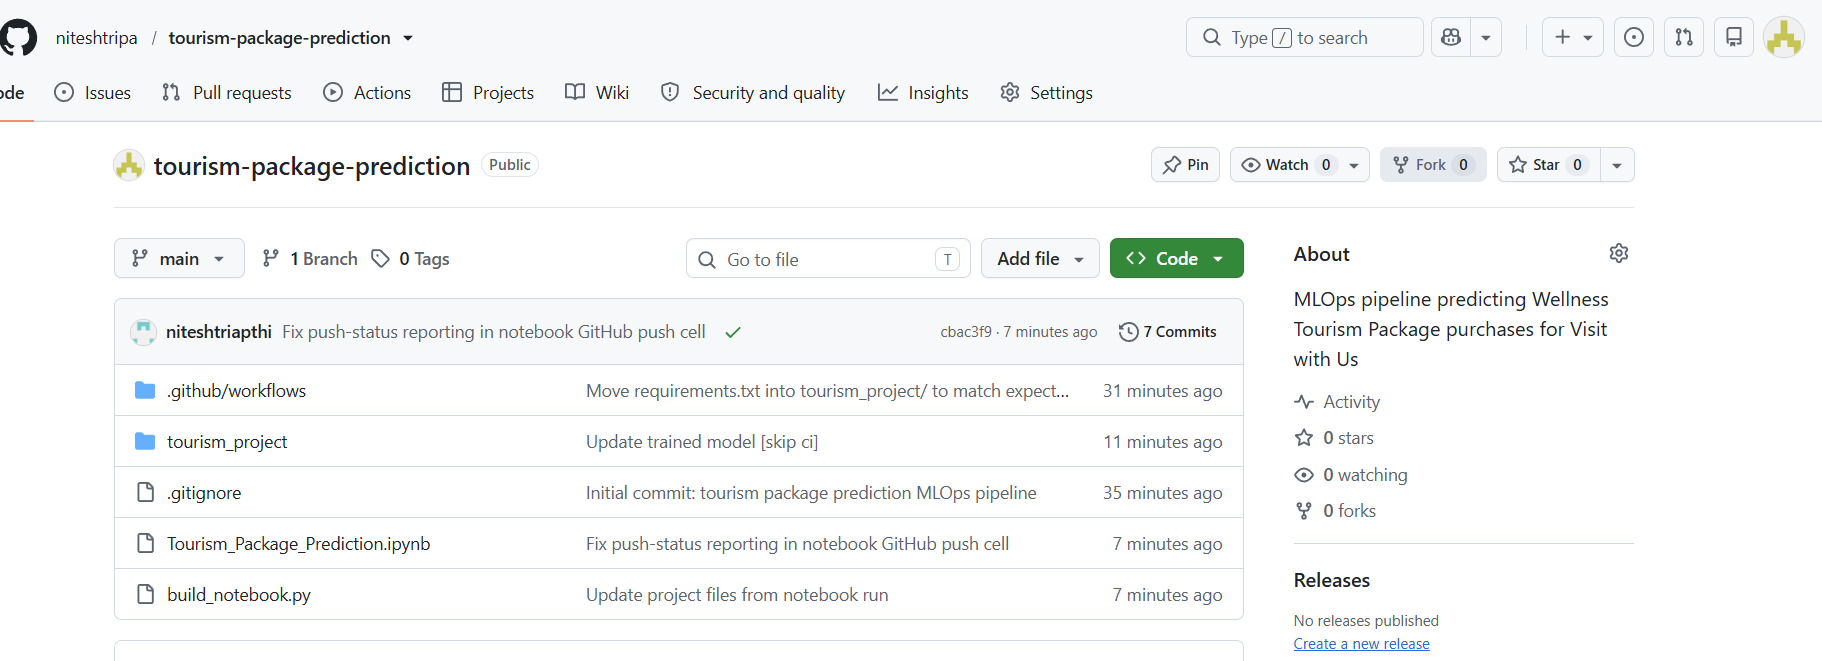

**Successful GitHub Actions workflow run:**

_(screenshot `github_actions_run.png` not found in `docs\screenshots/` — add it and rebuild)_

In [ ]:
print("Repository:", REPO_URL)
print("Actions:", REPO_URL + "/actions")

### Streamlit Community Cloud

- **App URL:** https://tourism-package-prediction-gqebjzdhhzrn33gpitu3mw.streamlit.app/

**Deployed app making a live prediction:**

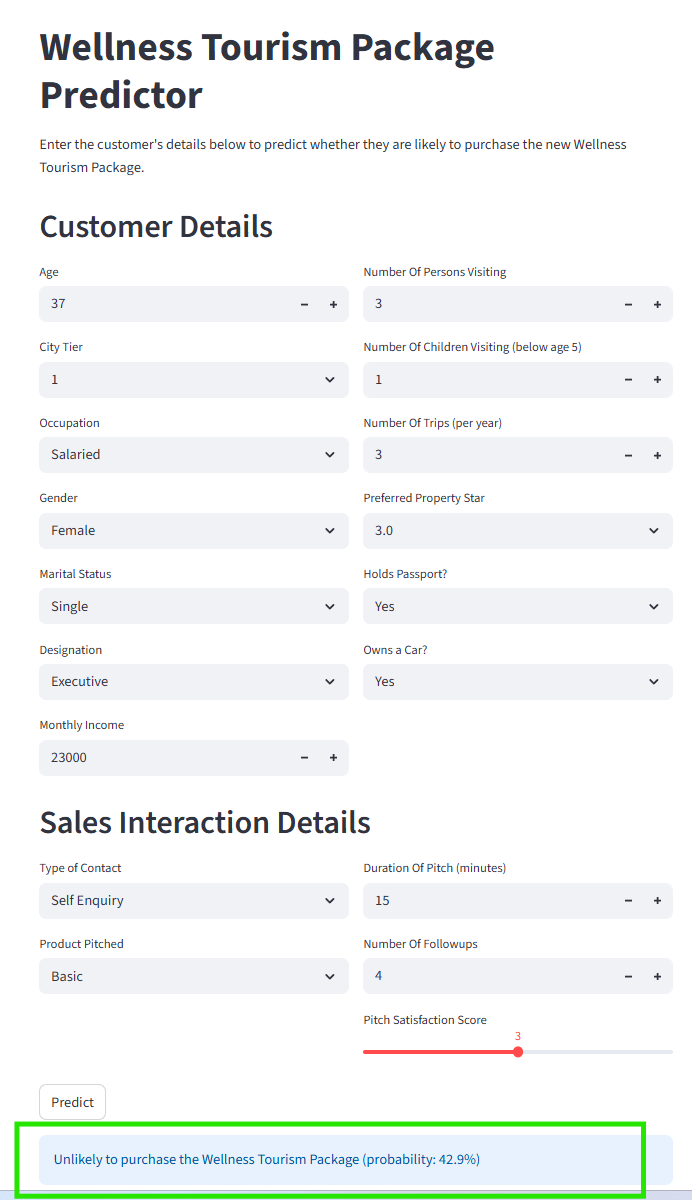

In [ ]:
STREAMLIT_APP_URL = "https://tourism-package-prediction-gqebjzdhhzrn33gpitu3mw.streamlit.app/"
print("Streamlit app:", STREAMLIT_APP_URL)

<font size=6 color="navyblue">Power Ahead!</font>

---